In [2]:
import pandas as pd
df_jugadores = pd.read_csv("jugadores_cebollitas.csv")
df_jugadores.head()

,jugador_id,nombre,posición,edad,partidos_jugados,goles,asistencias,pases_completados (%),tiros_al_arco,precisión_tiros (%),minutos_jugados
0,1,Tara Alvarez,Portero,18,25,2,5,89.0,8,78.2,2125
1,2,Carol Mcclain,Mediocampista,32,12,2,8,77.5,49,68.5,1032
2,3,Robert Martin,Defensa,26,12,4,5,87.3,1,71.4,816
3,4,Mr. Robert Turner,Defensa,25,17,2,4,75.9,9,35.8,1496
4,5,Christopher Kennedy,Defensa,35,23,1,7,83.5,0,0.0,2047


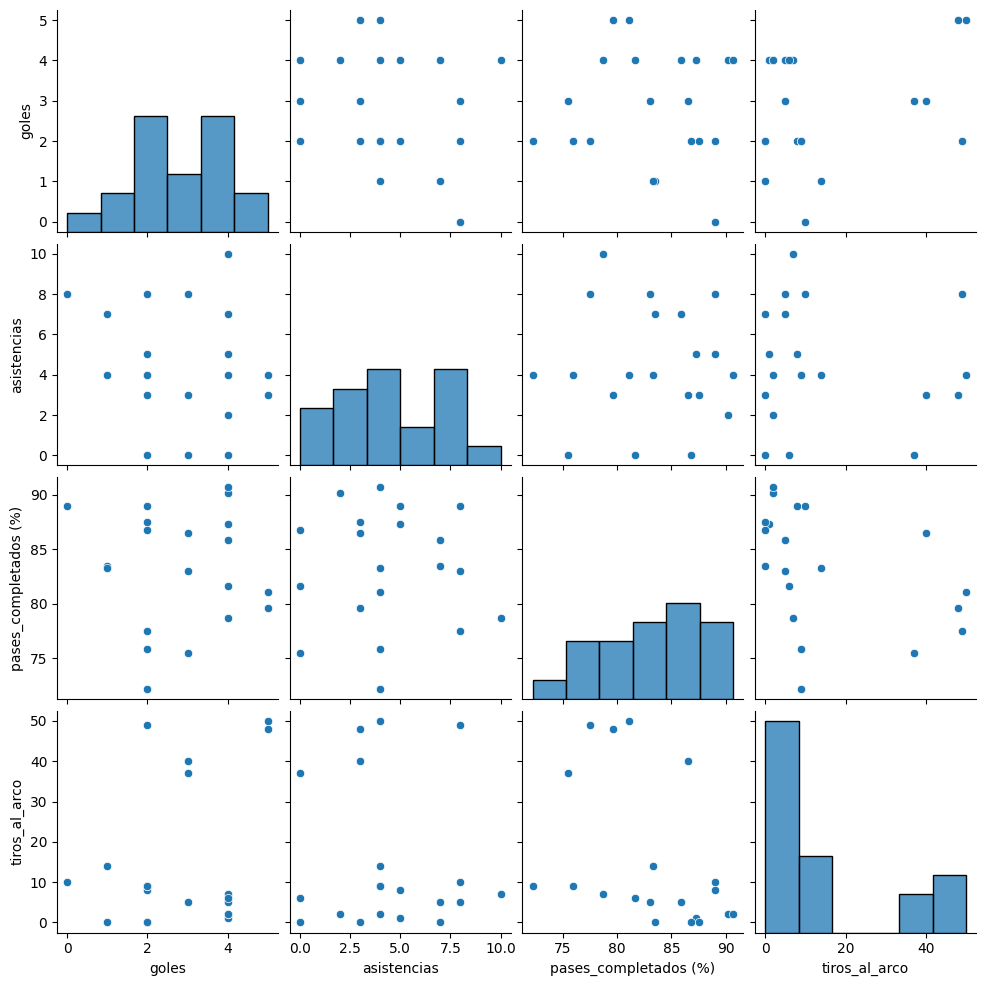

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df_jugadores[['goles', 'asistencias', 'pases_completados (%)', 'tiros_al_arco']])
plt.show()

In [8]:
from sklearn.cluster import KMeans

X = df_jugadores[['goles', 'asistencias', 'pases_completados (%)', 'tiros_al_arco']]

kmeans = KMeans(n_clusters=3, random_state=42)
df_jugadores['cluster'] = kmeans.fit_predict(X)

df_jugadores.head()

,jugador_id,nombre,posición,edad,partidos_jugados,goles,asistencias,pases_completados (%),tiros_al_arco,precisión_tiros (%),minutos_jugados,cluster,cluster_temp
0,1,Tara Alvarez,Portero,18,25,2,5,89.0,8,78.2,2125,1,3
1,2,Carol Mcclain,Mediocampista,32,12,2,8,77.5,49,68.5,1032,0,0
2,3,Robert Martin,Defensa,26,12,4,5,87.3,1,71.4,816,1,3
3,4,Mr. Robert Turner,Defensa,25,17,2,4,75.9,9,35.8,1496,2,2
4,5,Christopher Kennedy,Defensa,35,23,1,7,83.5,0,0.0,2047,1,1


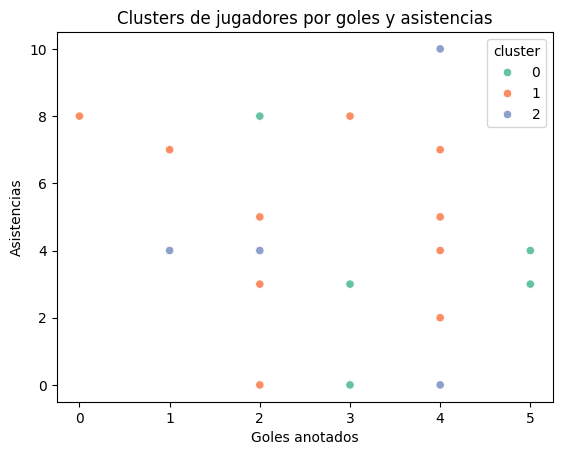

In [9]:
sns.scatterplot(x='goles', y='asistencias', hue='cluster', palette='Set2', data=df_jugadores)
plt.title("Clusters de jugadores por goles y asistencias")
plt.xlabel("Goles anotados")
plt.ylabel("Asistencias")
plt.show()

In [10]:
columnas_numericas = ['goles', 'asistencias', 'pases_completados (%)', 'tiros_al_arco']
perfiles = df_jugadores.groupby('cluster')[columnas_numericas].mean()
print(perfiles)

         goles  asistencias  pases_completados (%)  tiros_al_arco
cluster                                                          
0          3.6          3.6                  80.04           44.8
1          2.6          4.9                  87.29            3.3
2          2.6          4.4                  78.34            9.0


In [ ]:
import ipywidgets as widgets

def clustering_interactivo(k):
    km = KMeans(n_clusters=k, random_state=42)
    df_jugadores['cluster_temp'] = km.fit_predict(X)
    
    sns.scatterplot(x='goles', y='asistencias', hue='cluster_temp', palette='Set1', data=df_jugadores)
    plt.title(f"Clustering jugadores con {k} clusters")
    plt.xlabel("Goles")
    plt.ylabel("Asistencias")
    plt.show()

widgets.interactive(clustering_interactivo, k=(2,6,1))

interactive(children=(IntSlider(value=4, description='k', max=6, min=2), Output()), _dom_classes=('widget-inte…

k=2: Inercia=1059.19, Silueta=0.745
k=3: Inercia=683.05, Silueta=0.452
k=4: Inercia=531.78, Silueta=0.377
k=5: Inercia=431.89, Silueta=0.301
k=6: Inercia=313.79, Silueta=0.362
k=7: Inercia=246.07, Silueta=0.343
k=8: Inercia=188.74, Silueta=0.345
k=9: Inercia=146.24, Silueta=0.347
k=10: Inercia=107.35, Silueta=0.328


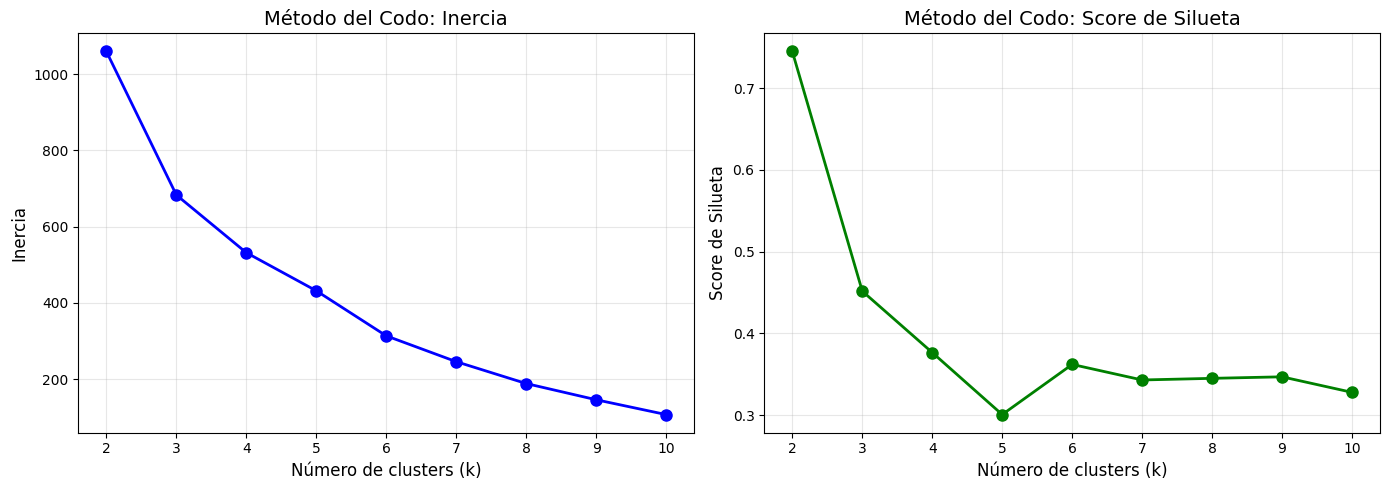


Número óptimo de clusters recomendado: 3 (según el análisis del codo)


In [13]:
from sklearn.metrics import silhouette_score
import numpy as np

# Calcular la inercia (suma de distancias al centroide más cercano) para diferentes números de clusters
# Esto nos ayuda a encontrar el número óptimo de clusters
inercias = []
siluetas = []
rango_k = range(2, 11)  # Probaremos de 2 a 10 clusters

for k in rango_k:
    # Entrenar KMeans con k clusters
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X)
    
    # Guardar la inercia (suma de distancias cuadradas dentro de clusters)
    inercias.append(kmeans_temp.inertia_)
    
    # Guardar el score de silueta (medida de cohesión de clusters, entre -1 y 1)
    siluetas.append(silhouette_score(X, kmeans_temp.labels_))
    print(f"k={k}: Inercia={kmeans_temp.inertia_:.2f}, Silueta={siluetas[-1]:.3f}")

# Visualizar el método del codo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Inercia vs Número de clusters
ax1.plot(rango_k, inercias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Número de clusters (k)', fontsize=12)
ax1.set_ylabel('Inercia', fontsize=12)
ax1.set_title('Método del Codo: Inercia', fontsize=14)
ax1.grid(True, alpha=0.3)

# Gráfico 2: Silueta vs Número de clusters
ax2.plot(rango_k, siluetas, 'go-', linewidth=2, markersize=8)
ax2.set_xlabel('Número de clusters (k)', fontsize=12)
ax2.set_ylabel('Score de Silueta', fontsize=12)
ax2.set_title('Método del Codo: Score de Silueta', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# El número óptimo de clusters es donde la curva de inercia forma un "codo"
# En este caso, observamos que después de k=3 la inercia decrece menos
print(f"\nNúmero óptimo de clusters recomendado: 3 (según el análisis del codo)")